# <p style="padding:10px;background-color:#007A7A;margin:0;color:white;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Import all you need</p>

In [2]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import yfinance as yf


# <p style="padding:10px;background-color:#007A7A;margin:0;color:white;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">get bitcoin price</p>  

In [3]:

# تعیین نماد بیت‌کوین و بازه زمانی مشخص شده
ticker = "BTC-USD"
start_date = "2025-03-06"
end_date = "2026-03-02"

# دریافت داده‌ها از یاهو فایننس
df_btc = yf.download(ticker, start=start_date, end=end_date)


[*********************100%***********************]  1 of 1 completed


In [5]:
df_btc.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-03-06,89961.726562,92804.937500,87852.140625,90622.359375,47749810486
2025-03-07,86742.671875,91191.046875,84717.679688,89963.281250,65945677657
2025-03-08,86154.593750,86847.265625,85247.484375,86742.656250,18206118081
2025-03-09,80601.039062,86471.132812,80052.484375,86154.304688,30899345977
2025-03-10,78532.000000,83955.929688,77420.593750,80597.148438,54061099422


In [6]:
df_btc.to_csv('data_price_BTC.csv')

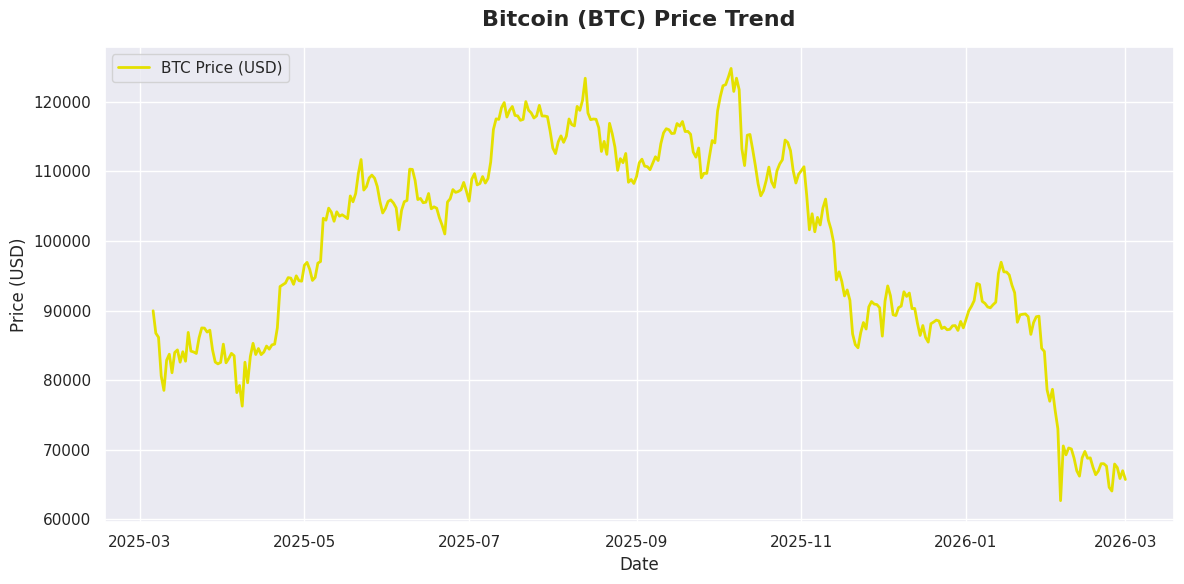

In [5]:
# ۱. تنظیم استایل نمودار برای ظاهری مدرن‌تر
sns.set_theme(style="darkgrid")

# ۲. ساخت یک قاب (Figure) برای نمودار
plt.figure(figsize=(12, 6))

# ۳. رسم نمودار خطی قیمت پایانی
# توجه: اگر تاریخ ایندکس دیتافریم است، از df_tweets.index استفاده می‌کنیم
plt.plot(df_btc.index, df_btc['Close'], color="#e4e000", linewidth=2, label='BTC Price (USD)')

# ۴. شخصی‌سازی و زیباسازی نمودار
plt.title('Bitcoin (BTC) Price Trend', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')

# ۵. بهینه‌سازی فاصله‌ها و نمایش نمودار
plt.tight_layout()
plt.show()

# <p style="padding:10px;background-color:#007A7A;margin:0;color:white;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Getting tweets relevant to Bitcoin</p>  

In [33]:
df_tweets = pd.read_csv('Sentiment_Twitte_For_BTC_250000.csv')

In [34]:
df_tweets.drop('Unnamed: 0' , inplace=True , axis=1)

In [35]:
df_tweets.sort_values('date' , ascending=True , inplace=True)

In [36]:
df_tweets['date'] = pd.to_datetime(df_tweets['date'])

In [37]:
df_tweets['date'] = df_tweets['date'].sort_values()

In [38]:
#df_tweets['sentiment'] = df_tweets['sentiment'].map({
#    'negative': 0,
#    'neutral': 1,
#    'positive': 2
#})

In [39]:
df_tweets.sentiment.value_counts()

sentiment
neutral     10696
positive     5996
negative     2268
Name: count, dtype: int64

In [40]:
df_tweets['score'] = df_tweets['score'].round(2)

In [41]:
df_tweets.head()

,user_name,date,text,score,sentiment
10289,THEWIZARD ( beware scammers ),2025-03-06,I beter wake up at 40 k \n\nGn fam\n\n#BTC,0.73,neutral
10290,Investing.com,2025-03-06,"*BITCOIN FALLS BELOW $39,000 AS CRYPTOS DECLIN...",0.63,neutral
10291,THEWIZARD ( beware scammers ),2025-03-06,I was wondering where all my money was. Then s...,0.64,neutral
10292,Shitty.eth,2025-03-06,@paoloardoino Just send us back to $70k again....,0.55,positive
10293,Binance,2025-03-06,Mining #Bitcoin is the process of creating new...,0.62,neutral


In [42]:
df_tweets.date.describe()

count                         18960
mean     2025-08-17 01:52:10.632911
min             2025-03-06 00:00:00
25%             2025-06-21 00:00:00
50%             2025-08-09 00:00:00
75%             2025-10-27 00:00:00
max             2026-03-02 00:00:00
Name: date, dtype: object

In [43]:
tweet_counts = df_tweets.groupby('date').size().reset_index(name='tweet_count')

tweet_counts

,date,tweet_count
0,2025-03-06,10
1,2025-03-07,45
2,2025-03-08,9
3,2025-03-09,26
4,2025-03-10,75
...,...,...
194,2026-02-18,61
195,2026-02-19,16
196,2026-02-22,11
197,2026-02-28,4


<Axes: xlabel='tweet_count', ylabel='date'>

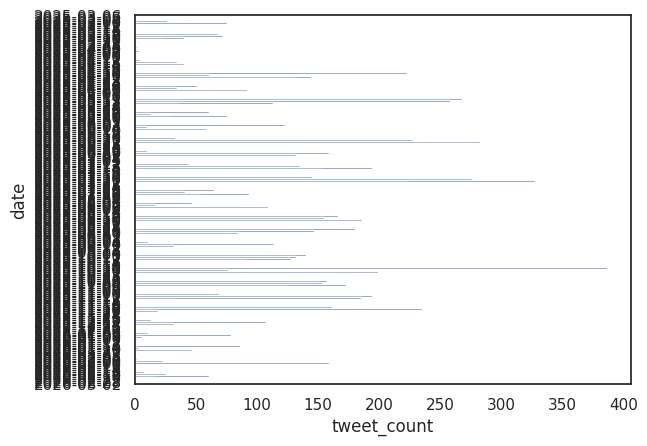

In [44]:
sns.barplot(tweet_counts , x= 'tweet_count' , y='date')

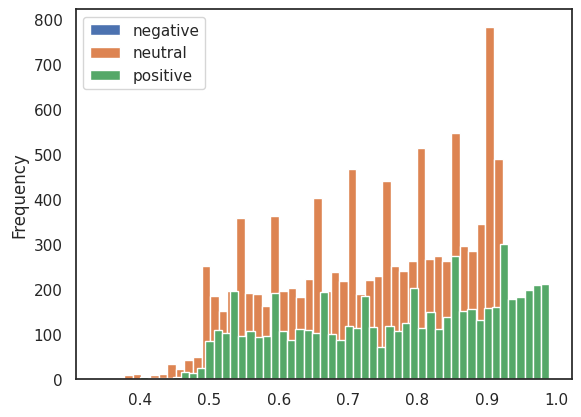

In [45]:
df_tweets.groupby("sentiment")["score"].plot(kind="hist", bins=50)
plt.legend()
plt.show()

# <p style="padding:10px;background-color:#007A7A;margin:0;color:white;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Merging two data frames</p> 


In [46]:
df_btc = pd.read_csv('data_price_BTC_cleaned.csv')

In [47]:
df_btc.head()

,date,close_price,high_price,low_price,open_price,volume
0,2025-03-06,89961.726562,92804.937500,87852.140625,90622.359375,47749810486
1,2025-03-07,86742.671875,91191.046875,84717.679688,89963.281250,65945677657
2,2025-03-08,86154.593750,86847.265625,85247.484375,86742.656250,18206118081
3,2025-03-09,80601.039062,86471.132812,80052.484375,86154.304688,30899345977
4,2025-03-10,78532.000000,83955.929688,77420.593750,80597.148438,54061099422


In [48]:
df_btc.info()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         361 non-null    str    
 1   close_price  361 non-null    float64
 2   high_price   361 non-null    float64
 3   low_price    361 non-null    float64
 4   open_price   361 non-null    float64
 5   volume       361 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 20.6 KB


In [49]:
df_tweets['date'] = pd.to_datetime(df_tweets['date']).dt.date
df_btc['date'] = pd.to_datetime(df_btc['date']).dt.date


sentiment_daily = df_tweets.groupby(['date', 'sentiment']).size().unstack(fill_value=0)

sentiment_daily.columns = ['Negative_Count', 'Neutral_Count', 'Positive_Count']
sentiment_daily['Total_Tweets'] = sentiment_daily.sum(axis=1)

df_analysis = pd.merge(df_btc, sentiment_daily, on='date', how='inner')

# <p style="padding:10px;background-color:#007A7A;margin:0;color:white;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Measurement of correlation value</p> 

In [50]:
df_analysis['Positive_Ratio'] = df_analysis['Positive_Count'] / df_analysis['Total_Tweets']
df_analysis['Negative_Ratio'] = df_analysis['Negative_Count'] / df_analysis['Total_Tweets']

correlation_pos = df_analysis['close_price'].corr(df_analysis['Positive_Ratio'])
correlation_neg = df_analysis['close_price'].corr(df_analysis['Negative_Ratio'])

print(f"همبستگی قیمت با توئیت‌های مثبت: {correlation_pos:.2f}")
print(f"همبستگی قیمت با توئیت‌های منفی: {correlation_neg:.2f}")

همبستگی قیمت با توئیت‌های مثبت: 0.15
همبستگی قیمت با توئیت‌های منفی: 0.10


# <p style="padding:10px;background-color:#007A7A;margin:0;color:white;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Showing the impact of tweets from over 1 million followers on the price of Bitcoin</p> 

In [51]:

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_analysis["date"],
        y=df_analysis["close_price"],
        name="BTC Price",
        yaxis="y1",
        mode="lines",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=df_analysis["date"],
        y=df_analysis["Positive_Ratio"],
        name="Positive Tweets %",
        yaxis="y2",
        mode="lines",
        line=dict(dash="dash")
    )
)

fig.add_trace(
    go.Scatter(
        x=df_analysis["date"],
        y=df_analysis["Negative_Ratio"],
        name="Negative Tweets %",
        yaxis="y2",
        mode="lines",
        line=dict(dash="dot")
    )
)

fig.update_layout(
    title="Bitcoin Price vs Twitter Sentiment Analysis",

    xaxis=dict(
        title="Date",
        rangeslider=dict(visible=True)  
    ),

    yaxis=dict(
        title="BTC Price (USD)",
        side="left"
    ),

    yaxis2=dict(
        title="Tweets Ratio",
        overlaying="y",
        side="right"
    ),

    hovermode="x unified",
    template="plotly_white",
    height=700
)

fig.show()

In [52]:
df_analysis["Positive_Smooth"] = (
    df_analysis["Positive_Ratio"]
    .rolling(window=10, center=True)
    .mean()
)

df_analysis["Negative_Smooth"] = (
    df_analysis["Negative_Ratio"]
    .rolling(window=10, center=True)
    .mean()
)

In [53]:
fig.add_trace(
    go.Scatter(
        x=df_analysis["date"],
        y=df_analysis["Positive_Smooth"],
        name="Positive Tweets % (10D MA)",
        yaxis="y2",
        mode="lines"
    )
)

fig.add_trace(
    go.Scatter(
        x=df_analysis["date"],
        y=df_analysis["Negative_Smooth"],
        name="Negative Tweets % (10D MA)",
        yaxis="y2",
        mode="lines"
    )
)